In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the cleaned training dataset
df = pd.read_csv("../data/clean_cs_training.csv")

# Define target and feature columns based on your updated schema
target_column = 'default' 
X = df.drop(columns=[target_column])
y = df[target_column]

# Split data into train and test sets (80% / 20%) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
print("Variables X_train and y_train are now initialized and ready for execution.")

Train Shape: (119512, 11) | Test Shape: (29879, 11)
Variables X_train and y_train are now initialized and ready for execution.


In [8]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline Model: Random Forest with class balancing
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Challenger Model: XGBoost with scale_pos_weight handling class imbalance
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)

# Evaluate using performance metrics suitable for imbalanced data
scoring = ['roc_auc', 'average_precision']

rf_cv = cross_validate(rf_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
xgb_cv = cross_validate(xgb_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

# Compile results for performance comparison
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Mean ROC-AUC': [rf_cv['test_roc_auc'].mean(), xgb_cv['test_roc_auc'].mean()],
    'Mean PR-AUC': [rf_cv['test_average_precision'].mean(), xgb_cv['test_average_precision'].mean()]
})
print(results)

           Model  Mean ROC-AUC  Mean PR-AUC
0  Random Forest      0.834558     0.340232
1        XGBoost      0.844502     0.363151


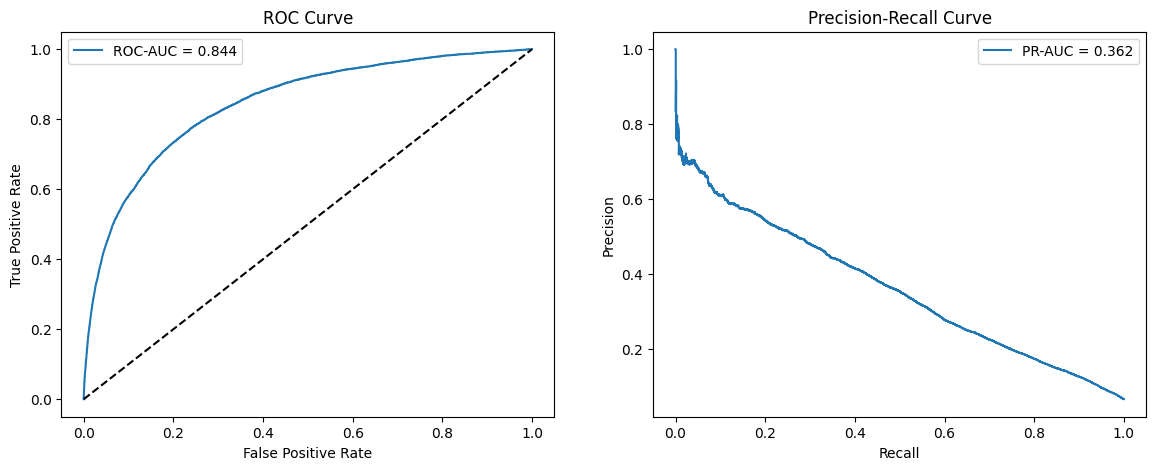

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold validation probabilities to prevent data leakage
y_scores = cross_val_predict(xgb_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

# Calculate curve coordinates
fpr, tpr, _ = roc_curve(y_train, y_scores)
precision, recall, thresholds = precision_recall_curve(y_train, y_scores)

# Plot validation curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax[0].plot(fpr, tpr, label=f'ROC-AUC = {auc(fpr, tpr):.3f}')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()

# Precision-Recall Curve
ax[1].plot(recall, precision, label=f'PR-AUC = {auc(recall, precision):.3f}')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

In [10]:
import numpy as np
from sklearn.metrics import f1_score

best_threshold = 0.5
best_f1 = 0

# Search for the optimal decision threshold that maximizes F1-Score on validation predictions
for th in np.arange(0.1, 0.9, 0.01):
    y_pred_th = (y_scores >= th).astype(int)
    score = f1_score(y_train, y_pred_th)
    if score > best_f1:
        best_f1 = score
        best_threshold = th

print(f"Optimal Threshold based on Validation: {best_threshold:.2f} (Best F1-Score: {best_f1:.3f})")

Optimal Threshold based on Validation: 0.73 (Best F1-Score: 0.415)


In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Train final model
xgb_model.fit(X_train, y_train)

# Predict probabilities on the test set
test_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply optimized threshold
test_pred = (test_probs >= best_threshold).astype(int)

print(classification_report(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("PR-AUC:", average_precision_score(y_test, test_probs))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95     27877
           1       0.36      0.52      0.43      2002

    accuracy                           0.91     29879
   macro avg       0.66      0.73      0.69     29879
weighted avg       0.92      0.91      0.91     29879

[[26031  1846]
 [  963  1039]]
ROC-AUC: 0.8451003654307453
PR-AUC: 0.3721030637519838


d:\Anaconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


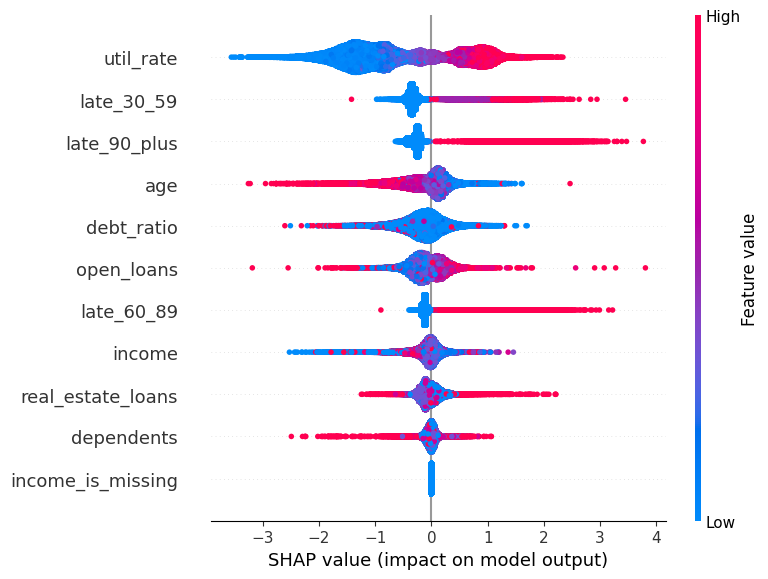

In [13]:
import shap

# Train final model on the full training set
xgb_model.fit(X_train, y_train)

# Initialize SHAP TreeExplainer and compute values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_train)

# Visualize feature importances and their directional impact
shap.summary_plot(shap_values, X_train)

In [ ]:
import joblib

joblib.dump(xgb_model,
            "../models/xgboost_credit_model.joblib")

# Evaluation 

--- Business Optimization Results ---
Optimal Decision Threshold: 0.44
Minimized Expected Cost:   $39,181,200.00

--- Core Credit Risk Metrics ---
ROC-AUC:          0.8445
PR-AUC:           0.3623
Gini Coefficient: 0.6889
KS Statistic:     0.5350
Brier Score Loss: 0.1226

--- Confusion Matrix (at Optimal Threshold) ---
[[89216 22289]
 [ 2135  5872]]

--- Classification Report (at Optimal Threshold) ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88    111505
           1       0.21      0.73      0.32      8007

    accuracy                           0.80    119512
   macro avg       0.59      0.77      0.60    119512
weighted avg       0.93      0.80      0.84    119512



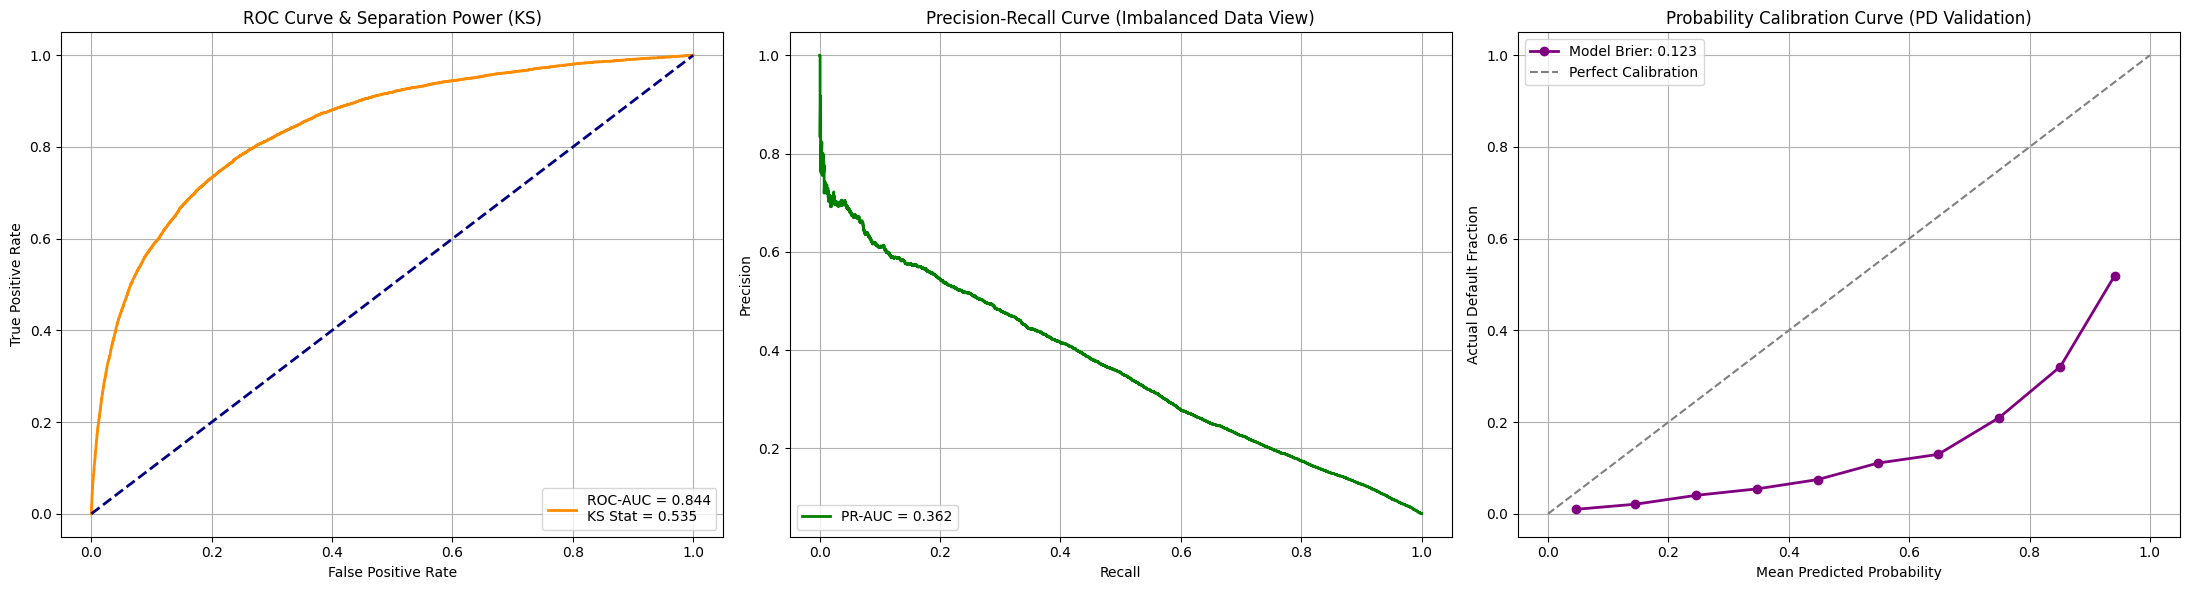

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc, 
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.calibration import calibration_curve

# 1. Threshold Optimization based on Business Expected Cost
cost_fn = 10000  # Financial loss per missed defaulter
cost_fp = 800    # Opportunity cost per wrongly rejected prime customer

best_threshold = 0.5
min_cost = float('inf')
cost_history = []
threshold_range = np.arange(0.05, 0.95, 0.01)

for th in threshold_range:
    y_pred_th = (y_scores >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_scores >= th).ravel()
    
    # Calculate total expected cost for this specific threshold
    expected_cost = (fn * cost_fn) + (fp * cost_fp)
    cost_history.append(expected_cost)
    
    if expected_cost < min_cost:
        min_cost = expected_cost
        best_threshold = th

print("--- Business Optimization Results ---")
print(f"Optimal Decision Threshold: {best_threshold:.2f}")
print(f"Minimized Expected Cost:   ${min_cost:,.2f}")

# 2. Core Credit Risk Metrics Calculation
fpr, tpr, roc_thresholds = roc_curve(y_train, y_scores)
precision, recall, pr_thresholds = precision_recall_curve(y_train, y_scores)

roc_auc = auc(fpr, tpr)
pr_auc = auc(recall, precision)
gini = 2 * roc_auc - 1
ks_stat = max(tpr - fpr)  # Correct Banking Interpretation
brier = brier_score_loss(y_train, y_scores)

print("\n--- Core Credit Risk Metrics ---")
print(f"ROC-AUC:          {roc_auc:.4f}")
print(f"PR-AUC:           {pr_auc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")
print(f"KS Statistic:     {ks_stat:.4f}")
print(f"Brier Score Loss: {brier:.4f}")

# 3. Confusion Matrix & Classification Report at Optimal Threshold
y_pred_optimal = (y_scores >= best_threshold).astype(int)
print("\n--- Confusion Matrix (at Optimal Threshold) ---")
print(confusion_matrix(y_train, y_pred_optimal))
print("\n--- Classification Report (at Optimal Threshold) ---")
print(classification_report(y_train, y_pred_optimal))

# 4. Plotting the Comprehensive Valuation Dashboard
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: ROC Curve & KS
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC = {roc_auc:.3f}\nKS Stat = {ks_stat:.3f}')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('ROC Curve & Separation Power (KS)')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(True)

# Subplot 2: Precision-Recall Curve
ax[1].plot(recall, precision, color='green', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax[1].set_title('Precision-Recall Curve (Imbalanced Data View)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(True)

# Subplot 3: Probability Calibration Curve
prob_true, prob_pred = calibration_curve(y_train, y_scores, n_bins=10)
ax[2].plot(prob_pred, prob_true, marker='o', linewidth=2, color='purple', label=f'Model Brier: {brier:.3f}')
ax[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
ax[2].set_title('Probability Calibration Curve (PD Validation)')
ax[2].set_xlabel('Mean Predicted Probability')
ax[2].set_ylabel('Actual Default Fraction')
ax[2].legend(loc="upper left")
ax[2].grid(True)

plt.tight_layout()
plt.show()